# 🧠 Brain MRI Tumor Classification using EfficientNetB0

This notebook presents a deep learning pipeline for multi-class brain tumor classification using **EfficientNetB0** with transfer learning and fine-tuning.

The model classifies MRI images into four categories:

- Glioma
- Meningioma
- Pituitary Tumor
- No Tumor

---

## 📌 Objectives

- Build an EfficientNetB0 classifier using transfer learning.
- Fine-tune the pretrained backbone.
- Evaluate the model using multiple performance metrics.
- Interpret model predictions using Grad-CAM.
- Visualize classification performance using ROC curves and confusion matrix.

---

# 📚 Import Required Libraries

Import all required libraries for data processing, visualization, model building, training, and evaluation.

In [1]:
import numpy as np
import pandas as pd
import random
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt             
import cv2                                 
import tensorflow as tf
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split 
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_curve, auc
from tqdm import tqdm
import warnings 
warnings.filterwarnings("ignore")

# 📂 Load Brain MRI Dataset

Load the MRI dataset and prepare the image paths and labels.

In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
IMAGE_SHAPE = (IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS)
LOSS_OPTIMIZER = 'categorical_crossentropy'
METRICS='accuracy'

In [3]:
class_names = os.listdir('/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing')
class_names.reverse()
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

class_names, class_names_label

(['glioma', 'meningioma', 'notumor', 'pituitary'],
 {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3})

In [4]:
path = '/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/'
splits = ["Training", "Testing"]

def load_data():
    
    df_all = pd.DataFrame(columns = ['image_path', 'label'])
    
    # Iterate through training and test sets
    for split in splits:
        
        images_path = []
        label = []
        
        print("Loading {}".format(split))
        
        # Iterate through each folder corresponding to a category
        root = os.path.join(path, split)
        for folder in os.listdir(root):
            
            # Iterate through each image in our folder
            
            for file in tqdm(os.listdir(os.path.join(root, folder))):
                images_path.append(os.path.join(os.path.join(root, folder), file))
                label.append(folder)  
        
        df_conc = pd.DataFrame({
                "image_path": images_path,
                "label": label
            })
        df_all = pd.concat([df_conc, df_all], ignore_index=True)

    return df_all

In [5]:
df_all = load_data()
df_all

Loading Training


100%|██████████| 1400/1400 [00:00<00:00, 519097.03it/s]


Loading Testing


100%|██████████| 400/400 [00:00<00:00, 420692.48it/s]


,image_path,label
0,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
1,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
2,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
3,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
4,/kaggle/input/datasets/masoudnickparvar/brain-...,pituitary
...,...,...
7195,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
7196,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
7197,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma
7198,/kaggle/input/datasets/masoudnickparvar/brain-...,glioma


# 📊 Dataset Exploration

Explore the dataset by:

- Number of images
- Number of classes
- Class distribution
- Sample images

In [6]:
df_all['label'].value_counts()

label
pituitary     1800
notumor       1800
meningioma    1800
glioma        1800
Name: count, dtype: int64

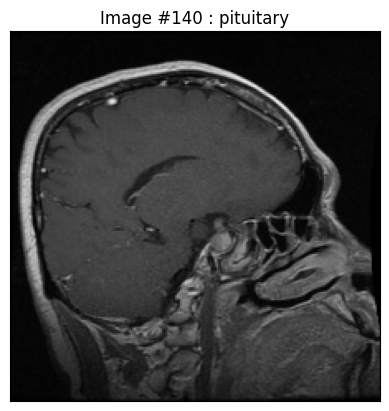

In [7]:
def display_random_image(class_names, images, labels):
    """
        Display a random image from the images array and its correspond label from the labels array.
    """
    
    images = images.to_numpy()
    labels = labels.to_numpy()
    
    index = np.random.randint(len(images))
    plt.figure()
    
    img = cv2.imread(images[index])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMAGE_SIZE) 
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title(f"Image #{index} : {labels[index]}")
    plt.show()

display_random_image(class_names, df_all['image_path'], df_all['label'])

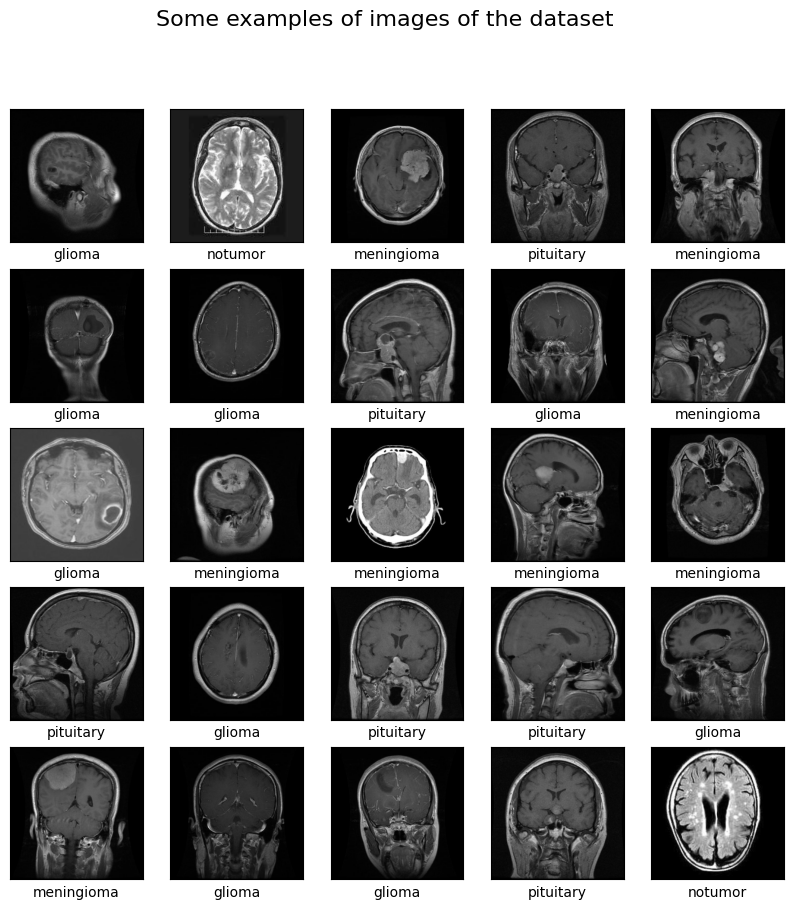

In [8]:
def display_examples(class_names, images, labels):
    """
        Display 25 random images from the images array with its corresponding labels
    """
    
    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        index = i + random.choice(range(images.shape[0])) - 25
        img = cv2.imread(images[index])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMAGE_SIZE)
        plt.imshow(img)
        plt.xlabel(labels[index])
    plt.show()

display_examples(class_names, df_all['image_path'], df_all['label'])

# 🛠 Data Preprocessing

Prepare the dataset for training.

Steps include:

- Train / Validation / Test split
- Image resizing
- Data augmentation
- EfficientNet preprocessing

In [9]:
df_train, df_test = train_test_split(
    df_all,
    test_size=0.1,
    stratify=df_all["label"],
    random_state=42
)

df_train, df_val = train_test_split(
    df_train,
    test_size=0.1,
    stratify=df_train["label"],
    random_state=42
)

print("Train size:", len(df_train))
print("Val size:", len(df_val))
print("Test size:", len(df_test))

Train size: 5832
Val size: 648
Test size: 720


# 🎨 Data Augmentation for EfficientNetB0
To improve model generalization and reduce overfitting, data augmentation is applied only to the training dataset.

The following transformations are used:

Small random rotations
Width shifting
Height shifting
Shear transformation
Zoom augmentation
Validation and test datasets remain unchanged except for preprocessing, allowing an unbiased evaluation.

In [10]:
eff_train_datagen = ImageDataGenerator(
    rotation_range=5,
    width_shift_range=0.01,
    height_shift_range=0.01,
    shear_range=0.05,
    zoom_range=0.1,
    preprocessing_function=efficient_preprocess_input,
    horizontal_flip=False,
    fill_mode="constant",         
    cval=0
)

eff_val_datagen = ImageDataGenerator(preprocessing_function=efficient_preprocess_input)

eff_train_gen = eff_train_datagen.flow_from_dataframe(
    dataframe = df_train,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "categorical",
    shuffle = True,
    batch_size = BATCH_SIZE,
    seed = 42
)

eff_val_gen = eff_val_datagen.flow_from_dataframe(
    dataframe = df_val,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "categorical",
    shuffle = False,
    batch_size = BATCH_SIZE,
    seed = 42
)
eff_test_gen = eff_val_datagen.flow_from_dataframe(
    dataframe = df_test,
    x_col = "image_path",
    y_col = "label",
    target_size = IMAGE_SIZE,
    color_mode = "rgb",  
    class_mode = "categorical",
    shuffle = False,
    batch_size = BATCH_SIZE,
    seed = 42
)

Found 5832 validated image filenames belonging to 4 classes.
Found 648 validated image filenames belonging to 4 classes.
Found 720 validated image filenames belonging to 4 classes.


In [11]:
print(eff_train_gen.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


# 🏗 Build EfficientNetB0 Model

Construct the classification model using:

- ImageNet pretrained EfficientNetB0
- Global Average Pooling
- Dropout
- Softmax Classification Layer

In [12]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=IMAGE_SHAPE
)

I0000 00:00:1783431410.293745      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783431410.299812      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output = Dense(4, activation="softmax")(x)

eff_model = Model(
    inputs=base_model.input,
    outputs=output
)

# ⚡ Compile Model

Compile the model using:

- Adam Optimizer
- Categorical Crossentropy
- Accuracy Metric

In [14]:
eff_model.compile(
    optimizer=Adam(1e-4),
    loss=LOSS_OPTIMIZER,
    metrics=[METRICS]
)

In [15]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=5,
    min_lr=1e-5
)

checkpoint = ModelCheckpoint(
    "EfficientNetB0_best_MBI.keras",
    monitor="val_accuracy",
    save_best_only=True
)

# 🚀 Transfer Learning

During the first training stage, all convolutional layers of EfficientNetB0 are frozen.

Only the newly added classification head is trained while the pretrained feature extractor remains unchanged.

This strategy allows the model to quickly adapt to the MRI dataset while preserving the valuable visual features learned from ImageNet.

Freezing the backbone also helps reduce training time and minimizes the risk of overfitting during the initial learning phase.

In [16]:
eff_history = eff_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=15,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15


2026-07-07 13:37:15.599115: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 13:37:15.742609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 13:37:16.088220: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 13:37:16.229073: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 13:37:17.033434: E external/local_xla/xla/stream_

 49/183 ━━━━━━━━━━━━━━━━━━━━ 1:10 528ms/step - accuracy: 0.2574 - loss: 1.4772

2026-07-07 13:37:56.508873: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 13:37:56.643808: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 13:37:56.956137: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 13:37:57.096148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 13:37:57.875197: E external/local_xla/xla/stream_

183/183 ━━━━━━━━━━━━━━━━━━━━ 154s 689ms/step - accuracy: 0.4419 - loss: 1.2297 - val_accuracy: 0.6358 - val_loss: 1.0162 - learning_rate: 1.0000e-04
Epoch 2/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 73s 399ms/step - accuracy: 0.6564 - loss: 0.9176 - val_accuracy: 0.7315 - val_loss: 0.8269 - learning_rate: 1.0000e-04
Epoch 3/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 72s 393ms/step - accuracy: 0.7186 - loss: 0.7853 - val_accuracy: 0.7438 - val_loss: 0.7359 - learning_rate: 1.0000e-04
Epoch 4/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 73s 399ms/step - accuracy: 0.7601 - loss: 0.6893 - val_accuracy: 0.7654 - val_loss: 0.6658 - learning_rate: 1.0000e-04
Epoch 5/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 72s 395ms/step - accuracy: 0.7805 - loss: 0.6322 - val_accuracy: 0.7778 - val_loss: 0.6279 - learning_rate: 1.0000e-04
Epoch 6/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 72s 395ms/step - accuracy: 0.7843 - loss: 0.6005 - val_accuracy: 0.7917 - val_loss: 0.5988 - learning_rate: 1.0000e-04
Epoch 7/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 73s 397ms/step -

# 🔧 Fine-Tuning
After the initial training phase, the last layers of EfficientNetB0 are unfrozen and fine-tuned using a very small learning rate.

Fine-tuning enables the pretrained feature extractor to gradually adapt to the specific characteristics of MRI images.

Only the final layers are updated while the majority of the network remains frozen, preserving the previously learned general visual representations.

This two-stage training strategy often improves the model's ability to capture domain-specific features without causing catastrophic forgetting.

In [17]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

eff_model.compile(
    optimizer=Adam(1e-4),
    loss=LOSS_OPTIMIZER,
    metrics=[METRICS]
)

eff_history_finetune = eff_model.fit(
    eff_train_gen,
    validation_data=eff_val_gen,
    epochs=15,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 126s 532ms/step - accuracy: 0.8517 - loss: 0.4188 - val_accuracy: 0.8843 - val_loss: 0.2903 - learning_rate: 1.0000e-04
Epoch 2/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 74s 404ms/step - accuracy: 0.9148 - loss: 0.2401 - val_accuracy: 0.9275 - val_loss: 0.1963 - learning_rate: 1.0000e-04
Epoch 3/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 73s 399ms/step - accuracy: 0.9390 - loss: 0.1769 - val_accuracy: 0.9259 - val_loss: 0.1781 - learning_rate: 1.0000e-04
Epoch 4/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 75s 407ms/step - accuracy: 0.9528 - loss: 0.1345 - val_accuracy: 0.9537 - val_loss: 0.1178 - learning_rate: 1.0000e-04
Epoch 5/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 73s 397ms/step - accuracy: 0.9650 - loss: 0.1072 - val_accuracy: 0.9537 - val_loss: 0.1321 - learning_rate: 1.0000e-04
Epoch 6/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 74s 406ms/step - accuracy: 0.9710 - loss: 0.0830 - val_accuracy: 0.9552 - val_loss: 0.1337 - learning_rate: 1.0000e-04
Epoch 7/15
183/183 ━━━━━━━━━━━━━━━━━━━━ 74s 4

# 📈 Model Evaluation
The trained model is evaluated using the unseen test dataset to measure its generalization capability.

The evaluation includes several performance metrics:

Test Accuracy
Precision
Recall
F1-score
Confusion Matrix
These metrics provide a comprehensive assessment of the model's diagnostic performance and reliability in detecting pneumonia cases.

In [18]:
print("Train class evaluate :", eff_model.evaluate(eff_train_gen))
print("Val class evaluate :", eff_model.evaluate(eff_val_gen))
print("Test class evaluate :", eff_model.evaluate(eff_test_gen))

183/183 ━━━━━━━━━━━━━━━━━━━━ 71s 390ms/step - accuracy: 0.9990 - loss: 0.0082
Train class evaluate : [0.008164013735949993, 0.998971164226532]
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9753 - loss: 0.0832
Val class evaluate : [0.08317027240991592, 0.9753086566925049]
22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9790 - loss: 0.0627

2026-07-07 14:17:26.397019: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:17:26.536786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:17:26.864147: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:17:27.005116: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:17:27.820653: E external/local_xla/xla/stream_

23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 713ms/step - accuracy: 0.9792 - loss: 0.0633
Test class evaluate : [0.06328935921192169, 0.9791666865348816]


# 📈 Training Curves

Visualize:

- Training Accuracy
- Validation Accuracy
- Training Loss
- Validation Loss

These curves help monitor convergence and detect overfitting.

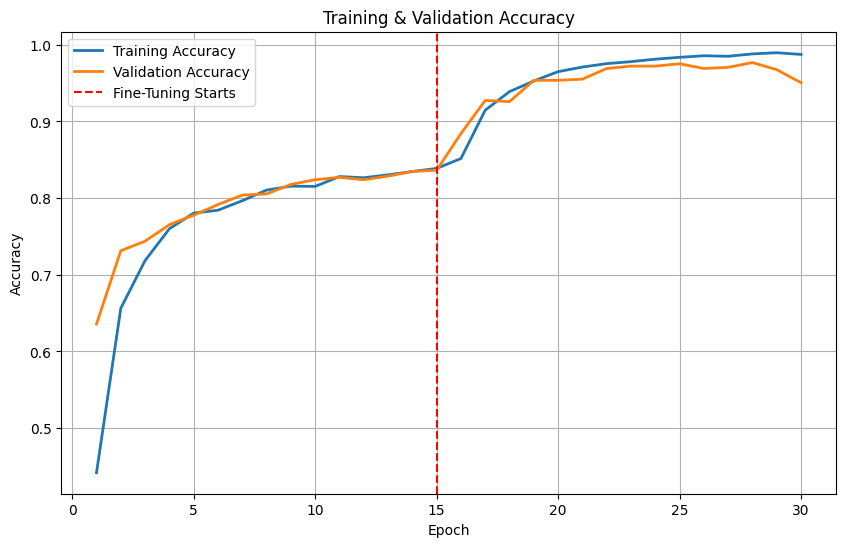

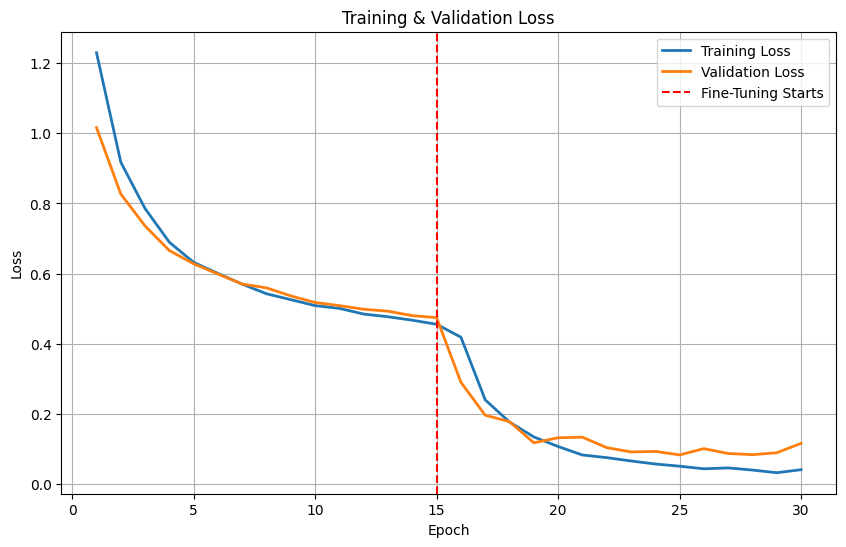

In [19]:
# ==============================
# Merge Accuracy
# ==============================
train_acc = (
    eff_history.history['accuracy'] +
    eff_history_finetune.history['accuracy']
)

val_acc = (
    eff_history.history['val_accuracy'] +
    eff_history_finetune.history['val_accuracy']
)

# ==============================
# Merge Loss
# ==============================
train_loss = (
    eff_history.history['loss'] +
    eff_history_finetune.history['loss']
)

val_loss = (
    eff_history.history['val_loss'] +
    eff_history_finetune.history['val_loss']
)

epochs = range(1, len(train_acc) + 1)

# Epoch where Fine-Tuning started
fine_tune_epoch = len(eff_history.history['accuracy'])

# ===================================
# Accuracy Plot
# ===================================
plt.figure(figsize=(10,6))

plt.plot(epochs, train_acc,
         label='Training Accuracy',
         linewidth=2)

plt.plot(epochs, val_acc,
         label='Validation Accuracy',
         linewidth=2)

plt.axvline(
    x=fine_tune_epoch,
    color='red',
    linestyle='--',
    label='Fine-Tuning Starts'
)

plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

# ===================================
# Loss Plot
# ===================================
plt.figure(figsize=(10,6))

plt.plot(epochs, train_loss,
         label='Training Loss',
         linewidth=2)

plt.plot(epochs, val_loss,
         label='Validation Loss',
         linewidth=2)

plt.axvline(
    x=fine_tune_epoch,
    color='red',
    linestyle='--',
    label='Fine-Tuning Starts'
)

plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [20]:
eff_test_gen.reset()

y_prob = eff_model.predict(eff_test_gen)
y_pred = np.argmax(y_prob, axis=1)

y_true = eff_test_gen.classes

23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 381ms/step


# 📊 Confusion Matrix Analysis¶
The confusion matrix provides detailed insight into the classification performance by comparing predicted labels with the true labels.

The following prediction categories are analyzed:

- True Positives (TP)
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
For medical diagnosis, false negatives are particularly critical because failing to detect pneumonia may delay treatment and increase patient risk.

Therefore, the confusion matrix offers a more informative evaluation than overall accuracy alone.

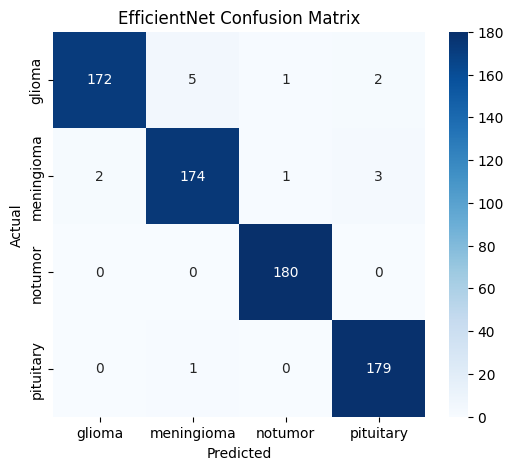

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=['glioma', 'meningioma', 'notumor', 'pituitary'],
    yticklabels=['glioma', 'meningioma', 'notumor', 'pituitary']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet Confusion Matrix")
plt.show()

# 📊 Classification Report

Compute:

- Precision
- Recall
- F1-score

for each tumor class.

In [22]:
eff_test_gen.reset()
pred = eff_model.predict(eff_test_gen)
pred = np.argmax(y_prob, axis=1)

print(classification_report(
    eff_test_gen.classes,
    pred,
    target_names=['glioma', 'meningioma', 'notumor', 'pituitary']
))

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
              precision    recall  f1-score   support

      glioma       0.99      0.96      0.97       180
  meningioma       0.97      0.97      0.97       180
     notumor       0.99      1.00      0.99       180
   pituitary       0.97      0.99      0.98       180

    accuracy                           0.98       720
   macro avg       0.98      0.98      0.98       720
weighted avg       0.98      0.98      0.98       720



# 🖼 Random Prediction Visualization

Display randomly selected MRI images along with:

- Ground Truth
- Predicted Label
- Prediction Confidence

2026-07-07 14:18:08.067535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:18:08.201360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:18:08.518567: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:18:08.659498: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:18:08.800108: E external/local_xla/xla/stream_

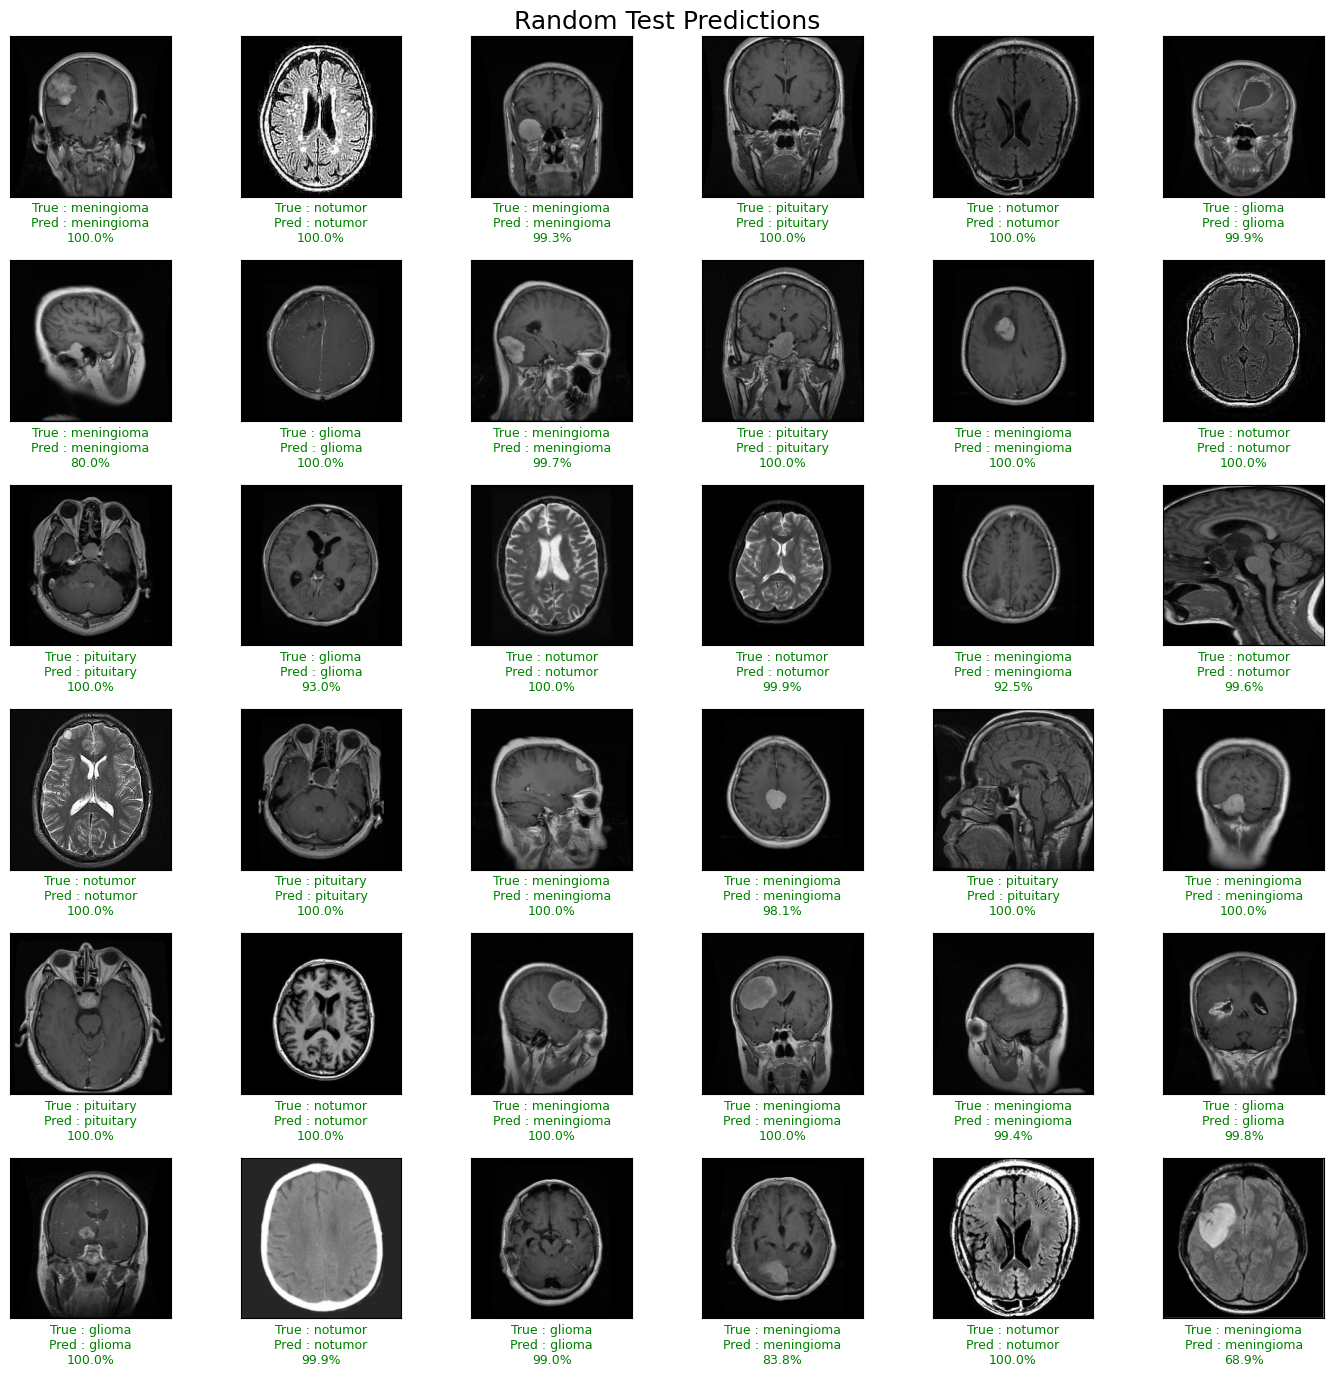

In [23]:
def display_predictions(
    model,
    class_names,
    images,
    labels,
    num_images=16,
    image_size=(224, 224)
):
    """
    Display random images with their true and predicted labels.
    Works with multiclass classification using softmax.
    """

    images = images.to_numpy()
    labels = labels.to_numpy()

    indices = random.sample(range(len(images)), num_images)

    batch = []
    original_imgs = []

    for idx in indices:

        img = cv2.imread(images[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, image_size)

        original_imgs.append(img)

        batch.append(img.astype(np.float32))

    batch = np.array(batch)
    batch = efficient_preprocess_input(batch)

    # Predict probabilities
    probs = model.predict(batch, verbose=0)

    # Predicted class index
    pred_idx = np.argmax(probs, axis=1)

    fig = plt.figure(figsize=(14, 14))
    fig.suptitle("Random Test Predictions", fontsize=18)

    rows = int(np.sqrt(num_images))
    cols = int(np.ceil(num_images / rows))

    for i, idx in enumerate(indices):

        plt.subplot(rows, cols, i + 1)

        plt.imshow(original_imgs[i])

        plt.xticks([])
        plt.yticks([])

        true_label = labels[idx]
        pred_label = class_names[pred_idx[i]]

        confidence = probs[i][pred_idx[i]] * 100

        color = "green" if true_label == pred_label else "red"

        plt.xlabel(
            f"True : {true_label}\n"
            f"Pred : {pred_label}\n"
            f"{confidence:.1f}%",
            color=color,
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

display_predictions(eff_model, class_names, df_test['image_path'], df_test['label'], num_images=36)

# 📈 ROC Curve

Generate One-vs-Rest ROC curves and compute the Area Under the Curve (AUC) for each tumor class.

In [24]:
eff_test_gen.reset()

y_prob = eff_model.predict(eff_test_gen, verbose=1)

y_true = eff_test_gen.classes

n_classes = len(eff_test_gen.class_indices)

y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step


In [25]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

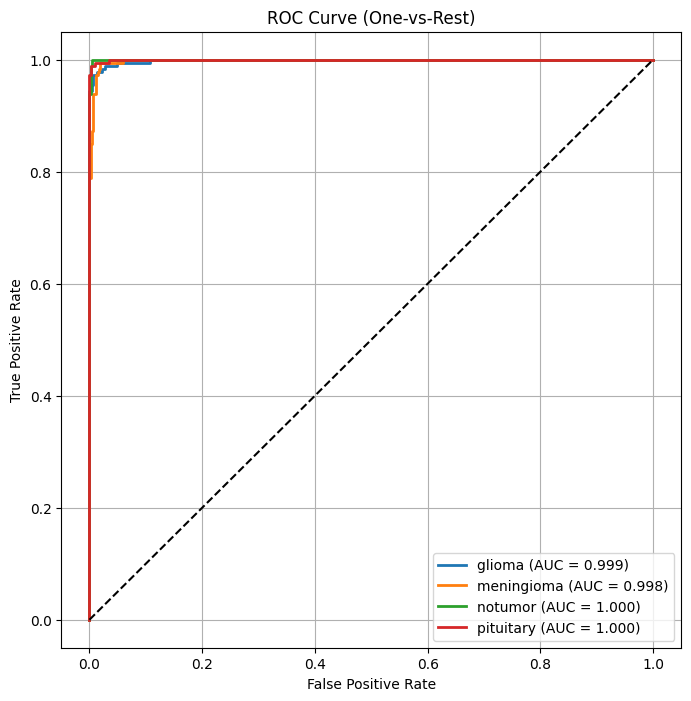

In [26]:
class_names = list(eff_test_gen.class_indices.keys())

plt.figure(figsize=(8,8))

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# 🔥 Grad-CAM Visualization

Interpret the model's decision by highlighting image regions that contribute most to the predicted class.

This improves model explainability and supports clinical interpretation.

In [27]:
for layer in reversed(eff_model.layers):
    if len(layer.output.shape) == 4:
        print(layer.name)
        break

top_activation


In [28]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap,0)

    heatmap /= tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [29]:
def overlay_gradcam(img, heatmap, alpha=0.4):

    heatmap = cv2.resize(
        heatmap,
        (img.shape[1], img.shape[0])
    )

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    superimposed = cv2.addWeighted(
        img,
        1-alpha,
        heatmap,
        alpha,
        0
    )

    return superimposed

In [30]:
def show_gradcam(model,
                 image_path,
                 last_conv_layer_name,
                 class_names,
                 image_size=(224,224)):

    img = cv2.imread(image_path)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img,image_size)

    img_array = np.expand_dims(img.astype(np.float32),0)

    img_array = efficient_preprocess_input(img_array)

    preds = model.predict(img_array, verbose=0)

    pred = np.argmax(preds)

    confidence = preds[0][pred]

    heatmap = make_gradcam_heatmap(
        img_array,
        model,
        last_conv_layer_name
    )

    gradcam = overlay_gradcam(img, heatmap)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)

    plt.imshow(img)

    plt.title("Original")

    plt.axis("off")

    plt.subplot(1,2,2)

    plt.imshow(gradcam)

    plt.title(
        f"{class_names[pred]}\nConfidence={confidence:.3f}"
    )

    plt.axis("off")

    plt.show()

2026-07-07 14:18:27.649294: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:18:27.783741: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:18:28.547683: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:18:28.681984: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 14:18:28.816404: E external/local_xla/xla/stream_

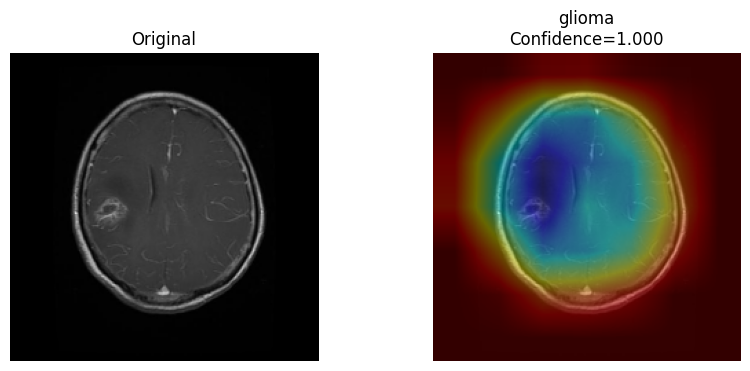

In [31]:
class_names = list(eff_test_gen.class_indices.keys())
index = random.choice(range(df_test.shape[0]))
show_gradcam(
    eff_model,
    df_test.iloc[index]["image_path"],
    "top_conv",
    class_names
)